In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import plt_conf as conf
import mpmath as mp
import sympy as sp
import pandas as pd
import matplotlib.cm as cm


# Local module with the functions shared across the figures below
import NMCG_utils as su


# Color palette used throughout the notebook
Cols = ("#06357a", '#533A98', '#136238', '#E7DA46', '#913902', "#FF9359")


conf.general()


## Solution for the dimensionless time tau

In [2]:
# Solution for an adimensional Tau
fValues = [0.01, 0.1, 1, 10]
H0Values = [67, 74]
qval = 1

# Sols[H0][i] -> solve_ivp solution for fValues[i], indexed as a list
Sols = {}
for H0val in H0Values:
    Sols[H0val] = []
    for fval in fValues:
        sol = su.solve_h_tau(H0val, fval, qval, tau_span=(0, 4))
        Sols[H0val].append(sol)


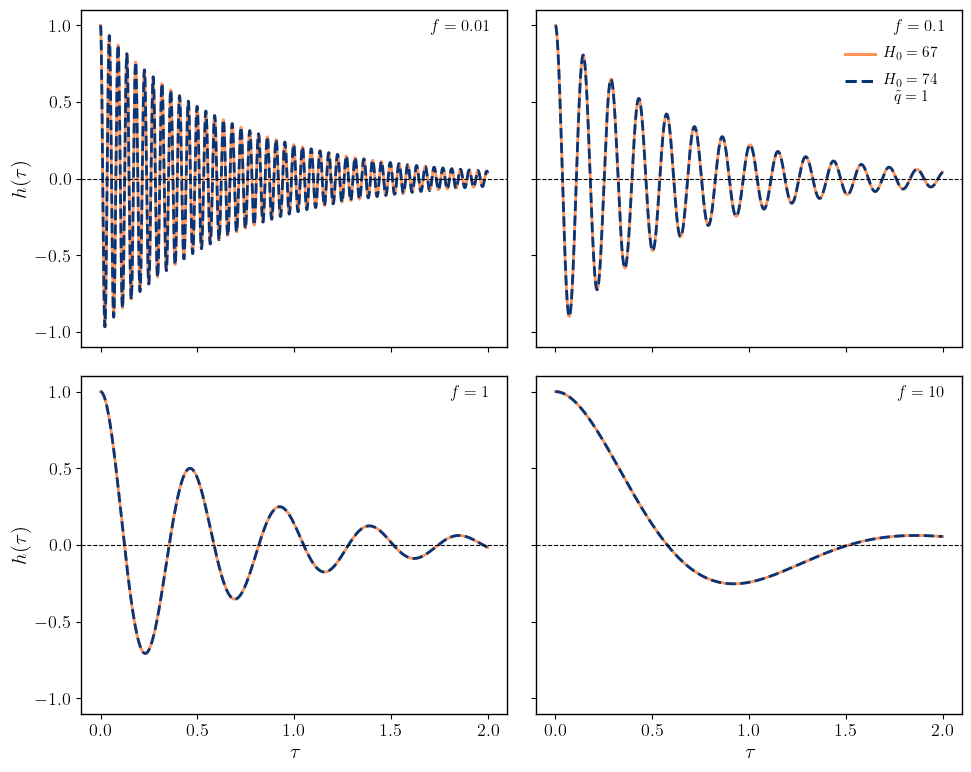

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

tau_plot = np.linspace(0, 2, 2000)

color67 = Cols[-1]
color74 = Cols[0]

for i, ax in enumerate(axes.flat):

    fval = fValues[i]

    h67 = Sols[67][i].sol(tau_plot)[0]
    h74 = Sols[74][i].sol(tau_plot)[0]

    ax.plot(tau_plot, h67, color=color67)
    ax.plot(tau_plot, h74, color=color74, linestyle='--')

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    ax.set_ylim(-1.1, 1.1)
    ax.set_yticks(np.arange(-1, 1.01, 0.5))

    if i in [0, 1]:
        ax.tick_params(axis="x", labelbottom=False)
        ax.set_xlabel("")
    else:
        ax.set_xlabel(r"$\tau$")

    if i in [1, 3]:
        ax.tick_params(axis="y", labelleft=False)
        ax.set_ylabel("")
    else:
        ax.set_ylabel(r"$h(\tau)$")

    ax.text(
        0.96, 0.97,
        rf"$f = {fval}$",
        transform=ax.transAxes,
        fontsize=12, ha="right", va="top"
    )

    if i == 1:
        su.draw_line_legend(
            ax,
            entries=[
                {"color": color67, "linestyle": "-", "label": r"$H_0 = 67$"},
                {"color": color74, "linestyle": "--", "label": r"$H_0 = 74$"},
            ],
            legend_x=0.725,
        )
        ax.text(
            0.725 + 0.115, 0.74, r"$\tilde q = 1$",
            transform=ax.transAxes,
            fontsize=11, ha="left", va="center", color="black"
        )

plt.tight_layout()


## Solution for the redshift z

In [4]:
"""Solution for z
(1+z)2h''(z)-2(1+z)h'(z)+[q_adi^2(1+z)^2+m_adid^2]h(z)=0
where m_adid=m/H0
q_adid=q/H0
"""

fValues = [0.01, 0.1, 1, 10]
H0Values = [67, 74]
qval = 1

# Sols[H0][f] -> solve_ivp solution, using su.solve_h_z for the actual
# ODE definition + integration
Sols = {}
for H0val in H0Values:
    Sols[H0val] = {}
    for fval in fValues:
        sol = su.solve_h_z(H0val, fval, qval, z_span=(0, 1), max_step=1e-3)
        Sols[H0val][fval] = sol


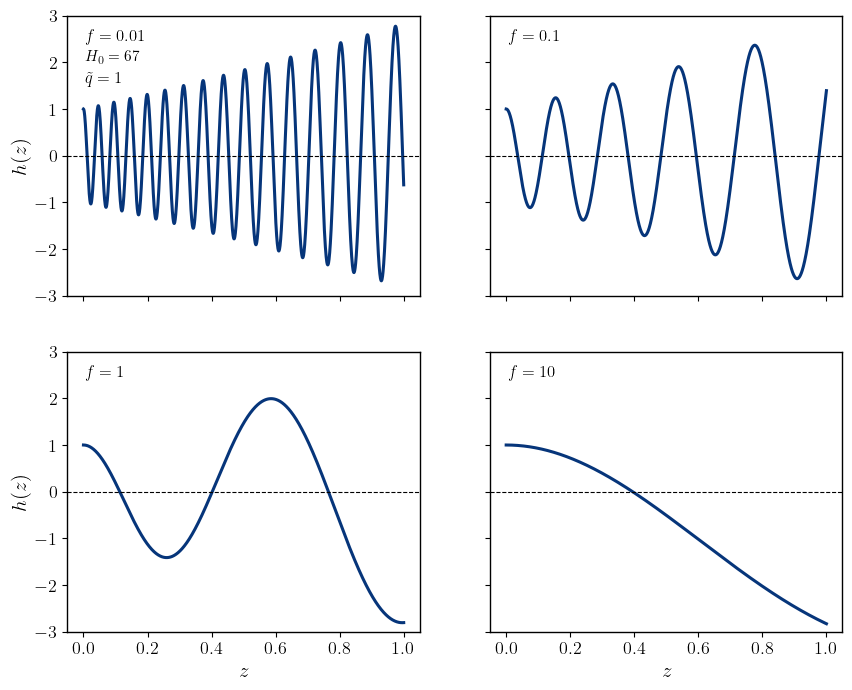

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

z_plot = np.linspace(0, 1, 2000)

color67 = Cols[0]

for i, ax in enumerate(axes.flat):

    fval = fValues[i]

    h67 = Sols[67][fval].sol(z_plot)[0]

    ax.plot(z_plot, h67, color=color67, linestyle="-", linewidth=2.2)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    ax.set_ylim(-3, 3)
    ax.set_xlabel(r"$z$")
    ax.set_ylabel(r"$h(z)$")

    if i in [1, 3]:
        ax.tick_params(axis="y", labelleft=False)
        ax.set_ylabel("")

    if i in [0, 1]:
        ax.tick_params(axis="x", labelbottom=False)
        ax.set_xlabel("")

    ax.text(
        0.05, 0.95,
        rf"$f = {fval}$",
        transform=ax.transAxes,
        fontsize=12, ha="left", va="top"
    )

    if i == 0:
        ax.text(
            0.05, 0.85,
            r"$H_0 = 67$",
            transform=ax.transAxes,
            fontsize=11, ha="left", va="center", color="black"
        )
        ax.text(
            0.05, 0.8,
            r"$\tilde q = 1$",
            transform=ax.transAxes,
            fontsize=12, ha="left", va="top", color="black"
        )

#fig.savefig("../Graficas/Scalaron_z_f.pdf", bbox_inches="tight")


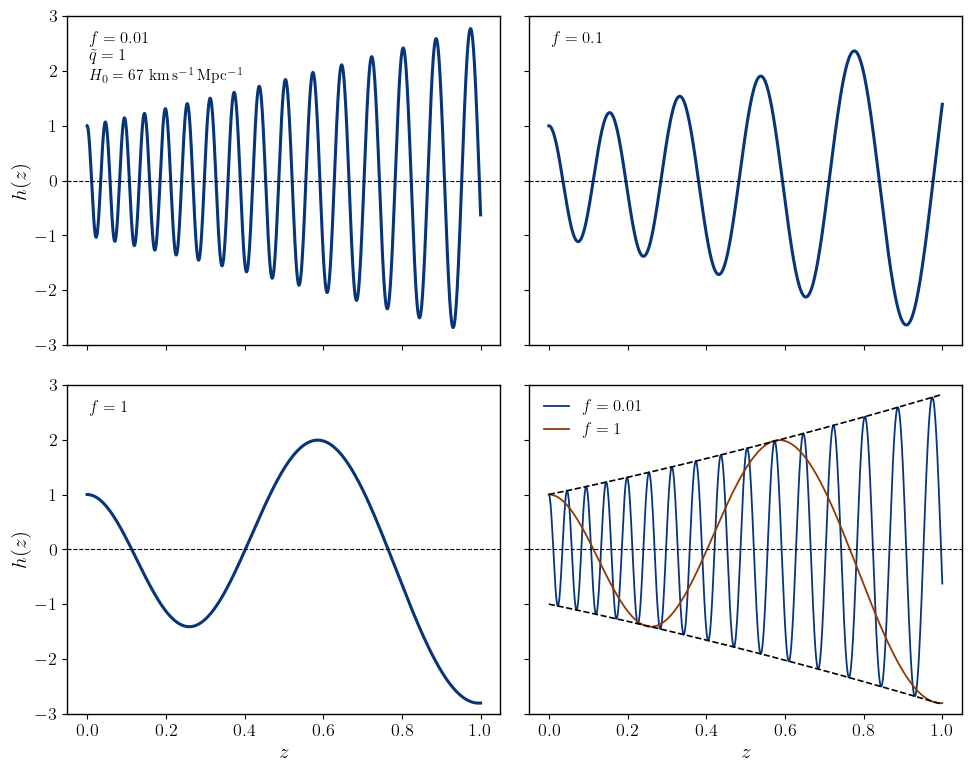

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

z_plot = np.linspace(0, 1, 2000)

color67 = Cols[0]
multi_colors = [Cols[0], Cols[2], Cols[4]]  # un color por cada f del panel 4

for i, ax in enumerate(axes.flat):

    if i < 3:
        fval = fValues[i]
        h67 = Sols[67][fval].sol(z_plot)[0]

        ax.plot(z_plot, h67, color=color67, linestyle="-", linewidth=2.2)

        ax.text(
            0.05, 0.95,
            rf"$f = {fval}$",
            transform=ax.transAxes,
            fontsize=12, ha="left", va="top"
        )

    else:
        # Panel 4: Envelope
        selected_fvals = [fValues[0], fValues[2]]
        selected_colors = [Cols[0], Cols[4]] 

        for fval, color in zip(selected_fvals, selected_colors):
            h_curve = Sols[67][fval].sol(z_plot)[0]
            ax.plot(z_plot, h_curve, color=color, linewidth=1.3,
             label=rf"$f={fval}$")

        
        h_ref = Sols[67][fValues[0]].sol(z_plot)[0]
        env_upper, env_lower = su.find_envelope(z_plot, h_ref)
        ax.plot(z_plot, env_upper, color="black", linewidth=1.2, linestyle="--")
        ax.plot(z_plot, env_lower, color="black", linewidth=1.2, linestyle="--")

        ax.legend(fontsize=12, loc="upper left", framealpha=0)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    ax.set_ylim(-3, 3)
    ax.set_xlabel(r"$z$")
    ax.set_ylabel(r"$h(z)$")

    if i in [1, 3]:
        ax.tick_params(axis="y", labelleft=False)
        ax.set_ylabel("")

    if i in [0, 1]:
        ax.tick_params(axis="x", labelbottom=False)
        ax.set_xlabel("")

    if i == 0:
        ax.text(
            0.05, 0.82,
            r"$H_0 = 67\ \mathrm{km\,s^{-1}\,Mpc^{-1}}$",
            transform=ax.transAxes,
            fontsize=11, ha="left", va="center", color="black"
        )
        ax.text(
            0.05, 0.9,
            r"$\tilde q = 1$",
            transform=ax.transAxes,
            fontsize=12, ha="left", va="top", color="black"
        )

plt.tight_layout()

fig.savefig("../Plots/Scalaron_z_f.pdf", bbox_inches="tight")


## Exact solution (Bessel functions), high precision

(0.0, 1.0)

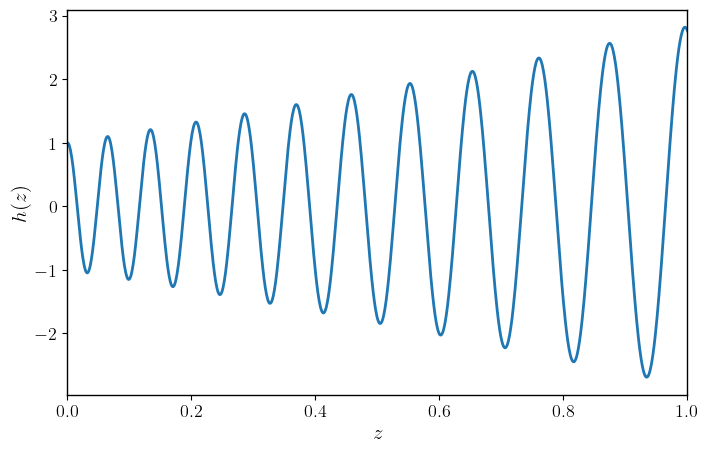

In [13]:
q = mp.mpf('1')
m_val = mp.mpf('100')

z_values = [mp.mpf(i) / 1000 for i in range(1001)]
h_values = su.h_exact_array(z_values, q, m_val, dps=500)

plt.figure(figsize=(8, 5))
plt.plot([float(z) for z in z_values], h_values)
plt.xlabel(r'$z$')
plt.ylabel(r'$h(z)$')
plt.xlim(0, 1)


## Which f reproduces a given (mass, GW frequency) pair

In [9]:
# If we fix a scalaron mass, which f value would reproduce it?
H0Val = 67
df = pd.read_csv("Data/Scalaron_Mass_Data.csv")
mass_min_col = df.columns[1]
mass_max_col = df.columns[2]

df_bounds = su.f_bounds_from_mass_table(df, H0Val, mass_min_col, mass_max_col)
df_bounds

,System,Inferior Bound (eV),Superior Bound (eV),ArXiv,f_min_roots,f_max_roots
0,Solar System,1.000000e-18,1.000000e-16,https://arxiv.org/pdf/2406.00351,3.921762e-28,3.921762e-32
1,Neutron Stars,1.000000e-16,1.000000e-09,1602.04766,3.921762e-32,3.921762e-46
2,Big Bang Nucleosynsthesis,1.000000e-16,1.000000e+04,[2310.19968] Constraining primordial black hol...,3.921762e-32,3.921762e-72
3,S2 Orbit,1.000000e-22,1.000000e-18,[2602.06151] Unscreening of f(R) gravity near ...,3.921762e-20,3.921762e-28
4,M87* Shadow,1.000000e-22,1.000000e-20,1904.12803,3.921762e-20,3.921762e-24


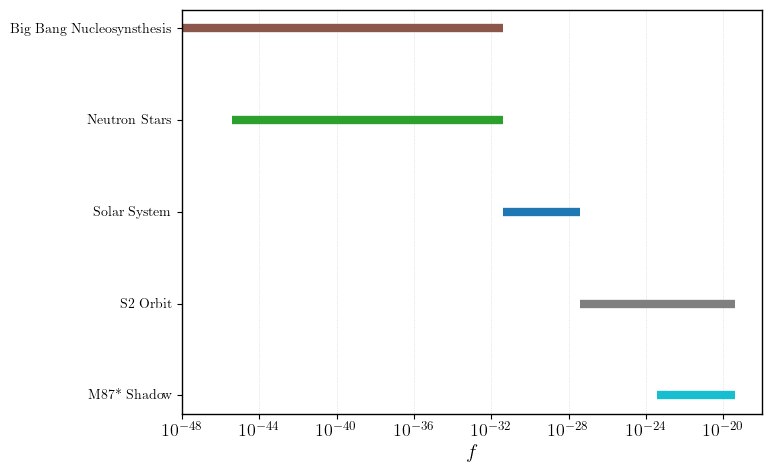

In [10]:
fig, ax = plt.subplots(figsize=(8,5))

exp_col = df.columns[0]
colors = cm.tab10(np.linspace(0, 1, len(df_bounds)))

rows = []
for (idx, row), color in zip(df_bounds.iterrows(), colors):
    f_lo = min(row["f_min_roots"], row["f_max_roots"])
    f_hi = max(row["f_min_roots"], row["f_max_roots"])
    if f_lo is None or f_hi is None:
        continue
    rows.append((row[exp_col], f_lo, f_hi, color))

rows.sort(key=lambda r: r[1])

for i, (label, f_lo, f_hi, color) in enumerate(rows):
    ax.plot([f_lo, f_hi], [i, i], color=color, linewidth=6, solid_capstyle="butt")

ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r[0] for r in rows], fontsize=10)
ax.set_xscale("log")
ax.set_xlabel("$f$")
ax.set_xlim(1e-48, 1e-18)
ax.invert_yaxis()  

ax.grid(axis="x", which="both", linestyle=":", linewidth=0.5, alpha=0.6)
plt.tight_layout()

fig.savefig("../Plots/Scalaron_f_Mass_Experiments.pdf", bbox_inches="tight")
